In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Load the cleaned analytical dataset
loan = pd.read_csv("data/loan_cleaned.csv", low_memory=False)

print("Shape:", loan.shape)
loan.head()

Shape: (38577, 34)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,total_rec_prncp,total_rec_int,recoveries,last_pymnt_amnt,default_flag,loan_year,loan_month,loan_month_name,int_rate_band,dti_band
0,5000,5000,36.0,10.65,162.87,B,B2,10+ years,RENT,24000.0,...,5000.00,863.16,0.00,171.62,0,2011,12,December,8-11.99,20-29.99
1,2500,2500,60.0,15.27,59.83,C,C4,< 1 year,RENT,30000.0,...,456.46,435.17,117.08,119.66,1,2011,12,December,12-15.99,<10
2,2400,2400,36.0,15.96,84.33,C,C5,10+ years,RENT,12252.0,...,2400.00,605.67,0.00,649.91,0,2011,12,December,12-15.99,<10
3,10000,10000,36.0,13.49,339.31,C,C1,10+ years,RENT,49200.0,...,10000.00,2214.92,0.00,357.48,0,2011,12,December,12-15.99,20-29.99
4,5000,5000,36.0,7.90,156.46,A,A4,3 years,RENT,36000.0,...,5000.00,632.21,0.00,161.03,0,2011,12,December,<8,10-19.99


In [4]:
# Define the modeling feature set
# Exclude post-outcome variables to avoid leakage
feature_cols = [
    "loan_amnt",
    "funded_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "loan_year"
]

target_col = "default_flag"

X = loan[feature_cols].copy()
y = loan[target_col].copy()

In [5]:
# Separate numeric and categorical features for preprocessing
numeric_features = [
    "loan_amnt",
    "funded_amnt",
    "term",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "loan_year"
]

categorical_features = [
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state"
]

In [6]:
# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
# Numeric preprocessing:
# impute missing values and standardize features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# impute missing values and one-hot encode categories
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing flows
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [8]:
# Train logistic regression for coefficient-based interpretation
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

log_reg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [9]:
# Get transformed feature names from the preprocessor
feature_names = log_reg_model.named_steps["preprocessor"].get_feature_names_out()

# Extract coefficients from the logistic regression model
coefficients = log_reg_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df.head()

,feature,coefficient
0,num__loan_amnt,0.062861
1,num__funded_amnt,-0.024516
2,num__term,0.273586
3,num__int_rate,0.494167
4,num__installment,-0.033050


In [10]:
# Positive coefficients increase predicted default risk
top_positive = coef_df.sort_values("coefficient", ascending=False).head(15)

# Negative coefficients decrease predicted default risk
top_negative = coef_df.sort_values("coefficient", ascending=True).head(15)

print("Top positive coefficients:")
display(top_positive)

print("\nTop negative coefficients:")
display(top_negative)

Top positive coefficients:


,feature,coefficient
118,cat__addr_state_NE,1.241166
87,cat__purpose_small_business,0.738814
121,cat__addr_state_NM,0.712875
122,cat__addr_state_NV,0.532691
3,num__int_rate,0.494167
90,cat__addr_state_AK,0.470613
99,cat__addr_state_FL,0.449167
130,cat__addr_state_SD,0.442130
51,cat__sub_grade_F5,0.380649
54,cat__sub_grade_G3,0.320534



Top negative coefficients:


,feature,coefficient
139,cat__addr_state_WY,-1.434883
131,cat__addr_state_TN,-0.809097
105,cat__addr_state_IN,-0.766696
97,cat__addr_state_DC,-0.536857
22,cat__sub_grade_A1,-0.451105
55,cat__sub_grade_G4,-0.446222
77,cat__purpose_credit_card,-0.402398
89,cat__purpose_wedding,-0.354876
5,num__annual_inc,-0.325091
115,cat__addr_state_MS,-0.305163


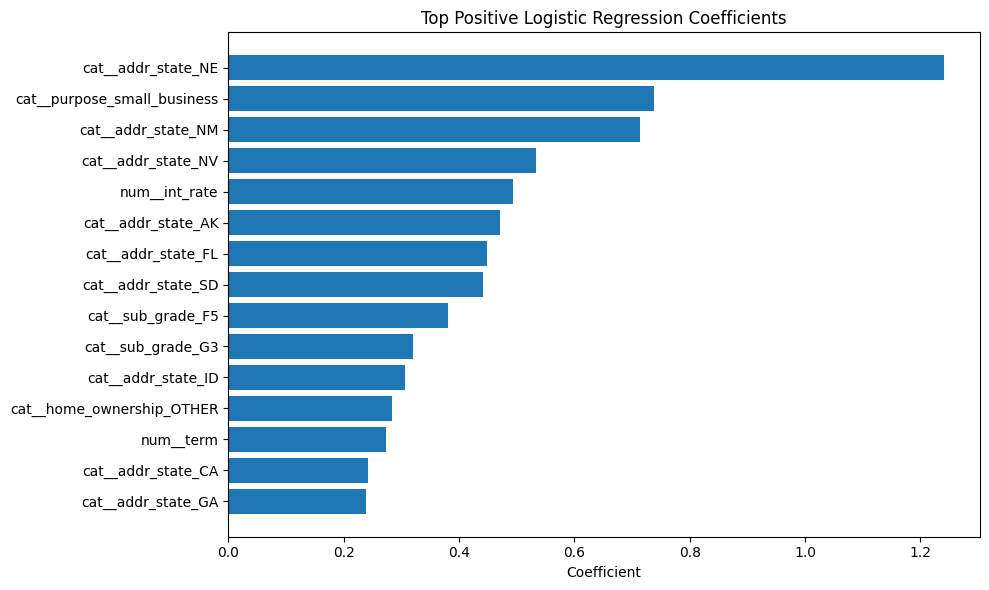

In [11]:
# Plot the strongest positive default risk signals from logistic regression
plt.figure(figsize=(10, 6))
plt.barh(top_positive["feature"][::-1], top_positive["coefficient"][::-1])
plt.title("Top Positive Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

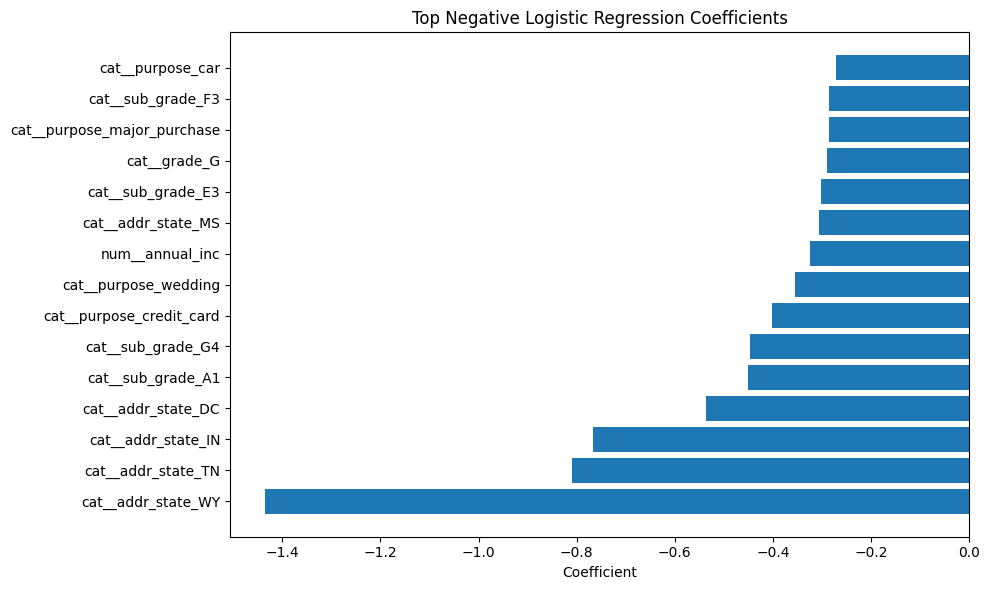

In [12]:
# Plot the strongest negative default risk signals from logistic regression
plt.figure(figsize=(10, 6))
plt.barh(top_negative["feature"], top_negative["coefficient"])
plt.title("Top Negative Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [13]:
# Train random forest for feature importance analysis
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [14]:
# Extract feature importance scores from the trained random forest
rf_importance = rf_model.named_steps["model"].feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": rf_model.named_steps["preprocessor"].get_feature_names_out(),
    "importance": rf_importance
}).sort_values("importance", ascending=False)

rf_importance_df.head(20)

,feature,importance
3,num__int_rate,0.164328
2,num__term,0.104415
15,cat__grade_A,0.083185
5,num__annual_inc,0.063023
12,num__revol_util,0.058664
4,num__installment,0.031200
6,num__dti,0.030586
1,num__funded_amnt,0.029800
11,num__revol_bal,0.028978
0,num__loan_amnt,0.026875


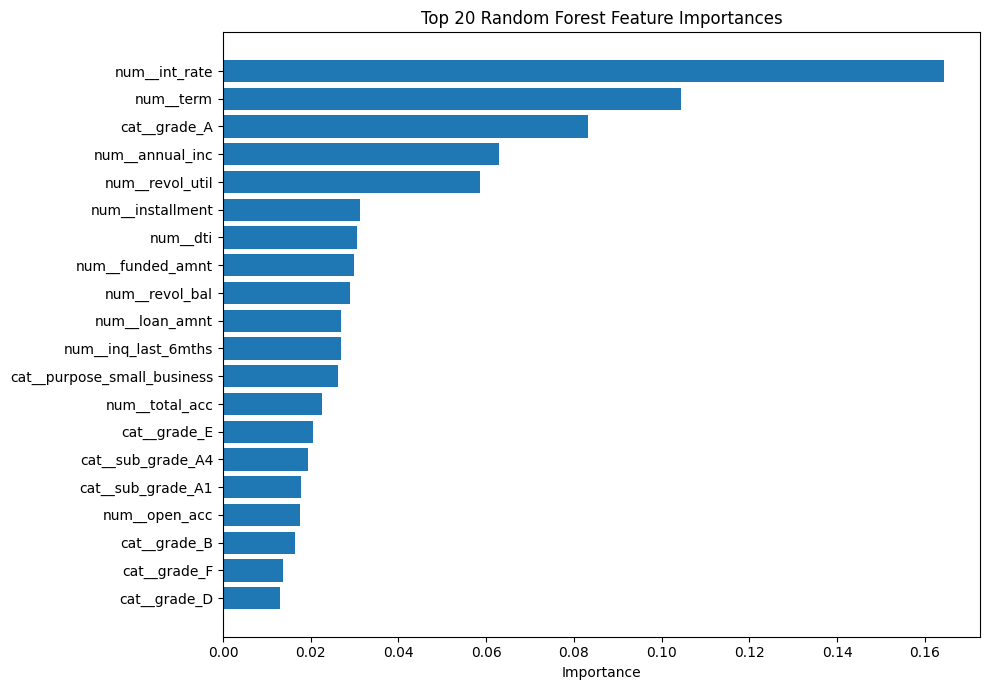

In [15]:
# Plot the top 20 most important features from random forest
top_rf = rf_importance_df.head(20)

plt.figure(figsize=(10, 7))
plt.barh(top_rf["feature"][::-1], top_rf["importance"][::-1])
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [16]:
# Create cleaner feature labels for easier interpretation in reporting
def clean_feature_name(name):
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    return name

coef_df["feature_clean"] = coef_df["feature"].apply(clean_feature_name)
rf_importance_df["feature_clean"] = rf_importance_df["feature"].apply(clean_feature_name)

coef_df.head()

,feature,coefficient,feature_clean
0,num__loan_amnt,0.062861,loan_amnt
1,num__funded_amnt,-0.024516,funded_amnt
2,num__term,0.273586,term
3,num__int_rate,0.494167,int_rate
4,num__installment,-0.033050,installment


In [17]:
# Create simplified summaries for reporting
top_logistic_summary = coef_df.sort_values("coefficient", ascending=False)[
    ["feature_clean", "coefficient"]
].head(10)

top_rf_summary = rf_importance_df[
    ["feature_clean", "importance"]
].head(10)

print("Top logistic regression risk signals:")
display(top_logistic_summary)

print("\nTop random forest features:")
display(top_rf_summary)

Top logistic regression risk signals:


,feature_clean,coefficient
118,addr_state_NE,1.241166
87,purpose_small_business,0.738814
121,addr_state_NM,0.712875
122,addr_state_NV,0.532691
3,int_rate,0.494167
90,addr_state_AK,0.470613
99,addr_state_FL,0.449167
130,addr_state_SD,0.442130
51,sub_grade_F5,0.380649
54,sub_grade_G3,0.320534



Top random forest features:


,feature_clean,importance
3,int_rate,0.164328
2,term,0.104415
15,grade_A,0.083185
5,annual_inc,0.063023
12,revol_util,0.058664
4,installment,0.031200
6,dti,0.030586
1,funded_amnt,0.029800
11,revol_bal,0.028978
0,loan_amnt,0.026875


In [18]:
# Print a simple business-style interpretation summary
print("Business Interpretation Summary")
print("-" * 40)
print("1. Borrower credit-related variables such as grade/sub-grade are expected to be strong predictors.")
print("2. Pricing variables such as interest rate often capture embedded risk differences.")
print("3. Debt burden and credit history indicators help explain higher default probability.")
print("4. State and purpose may contribute additional segmentation value, but often less than core credit features.")

Business Interpretation Summary
----------------------------------------
1. Borrower credit-related variables such as grade/sub-grade are expected to be strong predictors.
2. Pricing variables such as interest rate often capture embedded risk differences.
3. Debt burden and credit history indicators help explain higher default probability.
4. State and purpose may contribute additional segmentation value, but often less than core credit features.


In [19]:
# Save top interpretation outputs if you want to use them in a report or portfolio
top_logistic_summary.to_csv("data/top_logistic_coefficients.csv", index=False)
top_rf_summary.to_csv("data/top_random_forest_importance.csv", index=False)